In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
from skimage.morphology import skeletonize
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage as ndi
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import binary_erosion

In [436]:
os.getcwd()

'c:\\Users\\benjamin.tchitche\\Desktop\\Travail\\ElonSeg'

In [3]:
from models import UNetRegressor
from metrics import mae, r2_score,rmse
from utils import DistanceMapDataset

# Paths

In [ ]:
src = "D:\\Betterave"
data_path = "D:\\Betterave\\Dataset_mat"
save_path = "D:\\Betterave\\models"
model_name = "unet_smoothL1-model1.pth"

target_size = (512, 512)
batch_size = 10

# Dataset

In [119]:
test_dataset = DistanceMapDataset(
    image_dir= os.path.join(data_path, "test", "images"),
    mask_dir=os.path.join(data_path, "test", "masks"),
    target_size=target_size
)

train_dataset = DistanceMapDataset(
    image_dir= os.path.join(data_path, "train", "images"),
    mask_dir=os.path.join(data_path, "train", "masks"),
    target_size=target_size
)
val_dataset = DistanceMapDataset(
    image_dir= os.path.join(data_path, "val", "images"),
    mask_dir=os.path.join(data_path, "val", "masks"),
    target_size=target_size
)

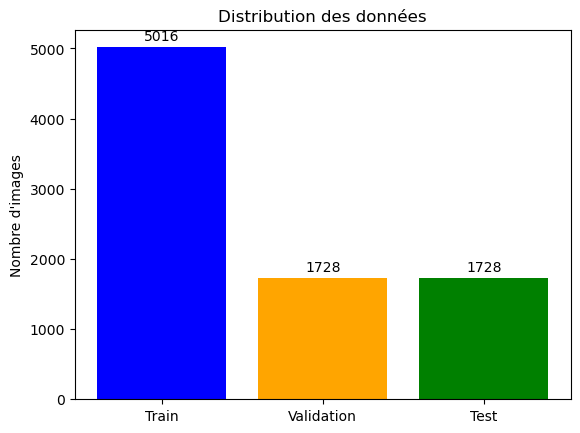

In [6]:
# visualisation des statistiques du dataset

values = [len(train_dataset), len(val_dataset), len(test_dataset)]
labels = ['Train', 'Validation', 'Test']
#plt.bar(labels, values, color=['blue', 'orange', 'green'])
plt.bar_label(plt.bar(labels, values, color=['blue', 'orange', 'green']), padding=3)
plt.title('Distribution des données')
plt.ylabel('Nombre d\'images')
plt.show()


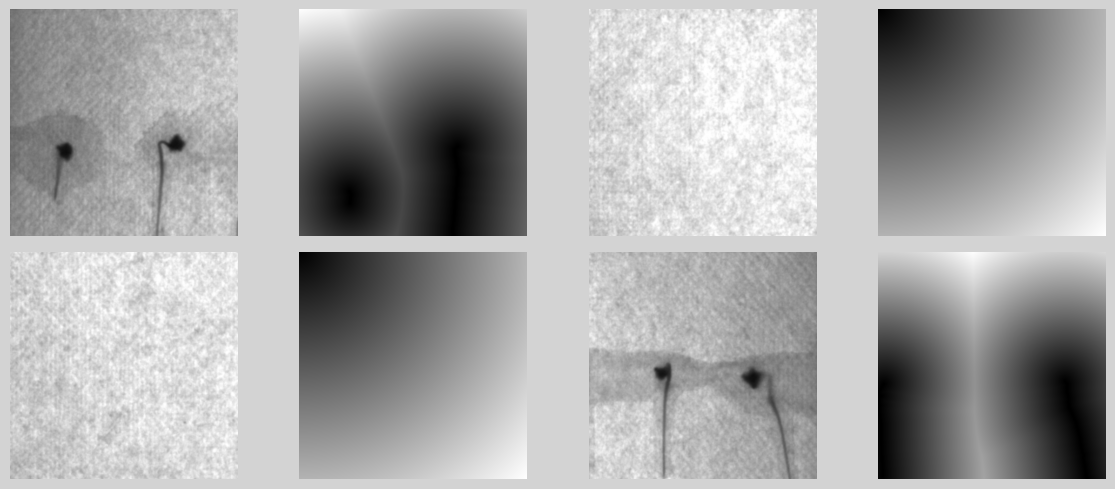

In [7]:
# visualisation des exemples
n = np.random.randint(0, len(train_dataset), size=8)

fig, axes = plt.subplots(2, 4, figsize=(12, 5), facecolor='lightgray')

axes = axes.flatten()
for i in range(0, len(n), 2):
    image, mask = train_dataset[n[i]]
    
    axes[i].axis('off')
    axes[i].imshow(image.permute(1, 2, 0).numpy())
    axes[i+1].imshow(mask.squeeze().numpy(), cmap='gray')
    axes[i+1].axis('off')


plt.tight_layout()
plt.show()

# Load history file

In [120]:

file_path = os.path.join(src,'checkpoints',f'training_history_{model_name}.json')

with open(file_path, 'r') as f:
    history = json.load(f)


In [121]:
epoch = np.arange(1,len(history["train_loss"])+1)

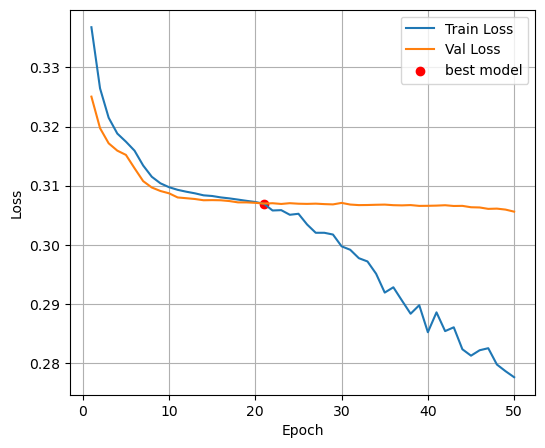

In [122]:

plt.figure(figsize=(6,5))
plt.plot(epoch, history["train_loss"], label="Train Loss")
plt.plot(epoch, history["val_loss"], label="Val Loss")
plt.scatter(history["best_epoch"][-1], history["best_val_loss"][-1], c="red", label = "best model")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

# Testins model 

In [123]:
def test_model(model, test_loader, device, model_path, metrics:dict = None):

    # Charger le modèle entraîné
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    results= {}

    for metric_name in metrics.keys():
        results[metric_name] = 0.0

    with torch.no_grad():
        for images, targets in tqdm(test_loader):

            images = images.to(device)
            targets = targets.to(device).float()

            outputs = model(images)

            for metric_name, metric_fn in metrics.items():
                metric_value = metric_fn(outputs.cpu(), targets.cpu())
                results[metric_name] += metric_value

    for metric_name in results:
        results[metric_name] /= len(test_loader)

    print("\n===== TEST RESULTS =====")
    for metric_name, metric_value in results.items():
        print(f"{metric_name}: {metric_value:.6f}")

    return results

In [124]:
metrics = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2_score
    }

In [125]:
def visualize_prediction(model, dataset, device, index=0):

    model.eval()

    image, target = dataset[index]

    image = image.unsqueeze(0).to(device)
    target = target.unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(image)

    image = image.cpu().squeeze().permute(1,2,0).numpy()
    target = target.cpu().squeeze().numpy()
    prediction = prediction.cpu().squeeze().numpy()

    print("Prediction stats:")
    print("Min:", prediction.min())
    print("Max:", prediction.max())
    print("Mean:", prediction.mean())
    print("Std :", prediction.std())

    plt.figure(figsize=(10,5))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(target, cmap="gray")
    plt.title("Verité terrain")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(prediction, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()



## Hyperparameters

In [126]:

learning_rate = 1e-5
num_epochs = 50
batch_size = 20
target_size = (512, 512)

In [127]:

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [128]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNetRegressor(in_channels=3)

In [85]:
best_model = str(save_path) + "\\" + model_name.replace(".pth", "_best.pth")
last_model = str(save_path) + "\\" + model_name.replace(".pth", "_last.pth")

In [129]:
test_model(
    model,
    test_loader,
    device,
    model_path= best_model,
    metrics=metrics
)

C:\Users\benjamin.tchitche\AppData\Local\Temp\ipykernel_16976\4216931476.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map


===== TEST RESULTS =====
MAE: 0.128704
RMSE: 0.176799
R2: 0.443876


{'MAE': tensor(0.1287), 'RMSE': tensor(0.1768), 'R2': tensor(0.4439)}

In [23]:
print(f"Test dataset size: {len(test_dataset)}")

Test dataset size: 1728


Prediction stats:
Min: 0.005457863
Max: 0.86683035
Mean: 0.33536965
Std : 0.24172284


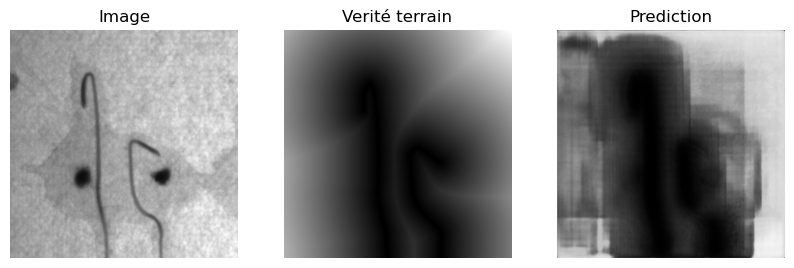

In [130]:
visualize_prediction(model, test_dataset, device, index=1720)

In [131]:
def predict(model,dataset, device, index=0, image=None):
    model.eval()

    if image is None:
        image, target = dataset[index]

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(image)

    prediction = prediction.cpu().squeeze().numpy()
    
    return prediction, target.cpu().squeeze().numpy(), image.cpu().squeeze().permute(1,2,0).numpy()
    

In [132]:
pred,target,image = predict(model, test_dataset, device, index=1720)

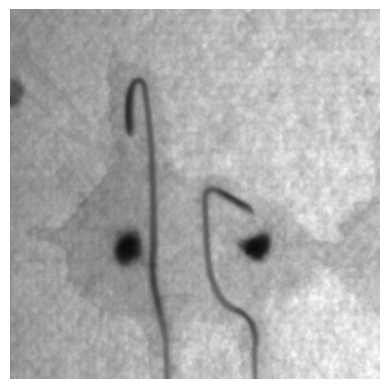

In [133]:
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

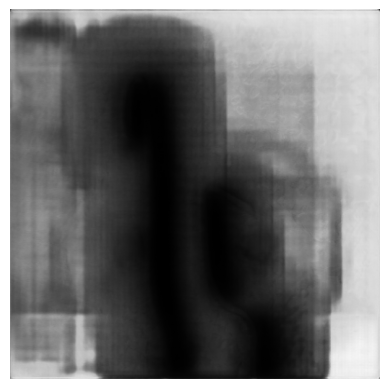

In [134]:
plt.imshow(pred, cmap="gray")
plt.axis("off")
plt.show()

In [135]:
from scipy.ndimage import gaussian_filter
distance_map = pred

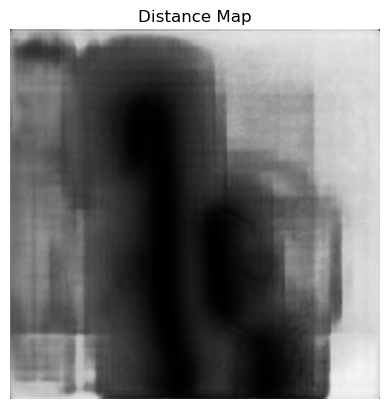

In [136]:
plt.imshow(distance_map, cmap="gray")
plt.title("Distance Map")
plt.axis("off")
plt.show()

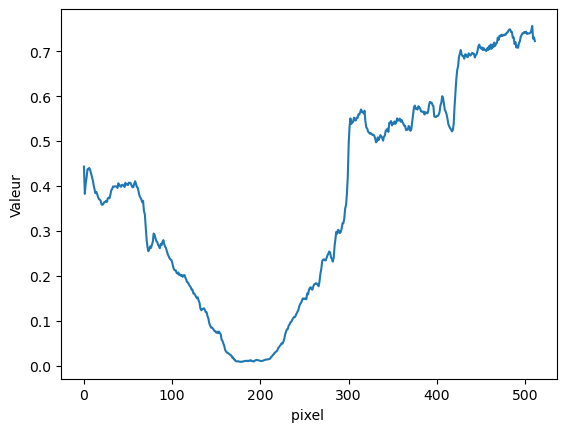

In [137]:
# profile longitudinal

values = distance_map[128,:]

plt.plot(values)
plt.xlabel("pixel ")
plt.ylabel("Valeur")
plt.show()

In [138]:

def watershed_from_distance(distance_map, threshold=0.8, min_distance=3):

    if isinstance(distance_map, torch.Tensor):
        distance_map = distance_map.detach().cpu().numpy()

    # masque des racines (bord = valeurs élevées)
    mask = distance_map < threshold

    # centres = minima → on cherche les minima locaux
    local_min = peak_local_max(
        -distance_map,
        min_distance=min_distance,
        labels=mask
    )

    markers = np.zeros(distance_map.shape, dtype=int)

    for i, (r, c) in enumerate(local_min):
        markers[r, c] = i + 1

    labels = watershed(distance_map, markers, mask=mask)

    # lisser les frontières
    labels = ndi.morphology.grey_closing(labels, size=(3, 3))

    return gaussian_filter(labels, sigma=1)

In [167]:
distance_map = pred

labels = watershed_from_distance(distance_map, threshold=0.03, min_distance=5).astype(np.bool_)

C:\Users\benjamin.tchitche\AppData\Local\Temp\ipykernel_16976\2273008634.py:24: DeprecationWarning: Please import `grey_closing` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  labels = ndi.morphology.grey_closing(labels, size=(3, 3))


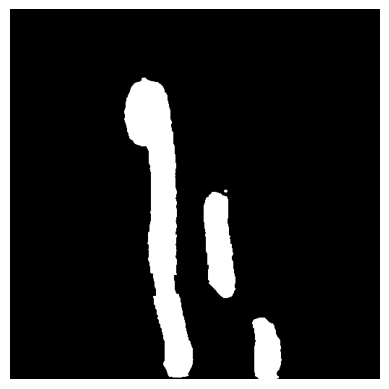

In [168]:
plt.imshow(labels, cmap="gray")
plt.axis("off")
plt.show()

In [169]:
pred_squelton = skeletonize(labels)

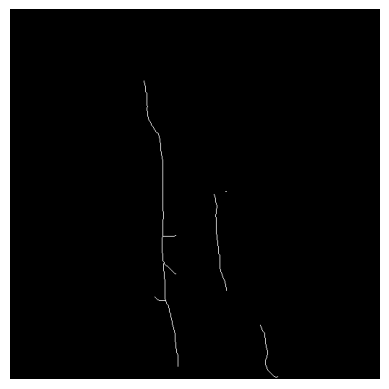

In [170]:
plt.imshow(pred_squelton, cmap="gray")
plt.axis("off")
plt.show()

C:\Users\benjamin.tchitche\AppData\Local\Temp\ipykernel_16976\2273008634.py:24: DeprecationWarning: Please import `grey_closing` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  labels = ndi.morphology.grey_closing(labels, size=(3, 3))


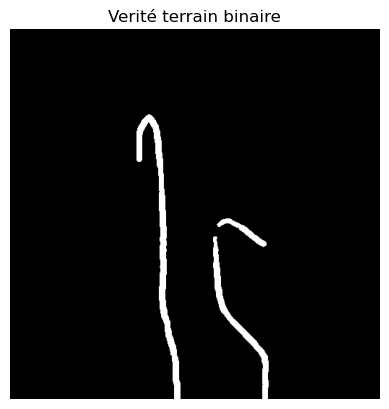

In [171]:

target_binary = watershed_from_distance(target, threshold=0.007, min_distance=5).astype(np.bool_)

plt.imshow(target_binary, cmap="gray")
plt.title("Verité terrain binaire")
plt.axis("off")
plt.show()

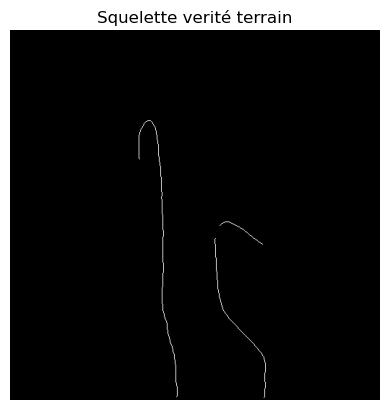

In [172]:
target_squelton = skeletonize(target_binary).astype(float)
plt.imshow(target_squelton, cmap="gray")
plt.title("Squelette verité terrain")
plt.axis("off")
plt.show()

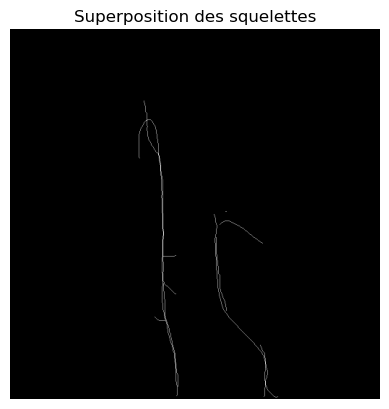

In [173]:
uni = pred_squelton + target_squelton

plt.imshow(uni, cmap="gray")
plt.title("Superposition des squelettes")
plt.axis("off")
plt.show()

In [157]:
union = np.logical_or(pred_squelton, target_squelton)
intersection = np.logical_and(pred_squelton, target_squelton)

In [174]:

print("Union:", union.sum())
print("Intersection:", intersection.sum())

print("iou:", compute_iou(pred_squelton, target_squelton))

Union: 1156
Intersection: 148
iou: 0.08562450903377848


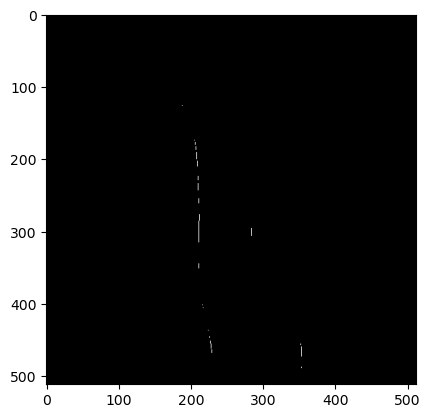

In [175]:
plt.imshow(intersection, cmap="gray")
plt.show() 

In [176]:
def compute_iou(pred_binary, target_binary):
    intersection = np.logical_and(pred_binary, target_binary).sum()
    union = np.logical_or(pred_binary, target_binary).sum()
    
    if union == 0:
        return 1.0
    
    iou = intersection / union
    return iou

In [177]:
def dice_coeff(pred_binary, target_binary):
    intersection = np.logical_and(pred_binary, target_binary).sum()
    total_pixels = pred_binary.sum() + target_binary.sum()
    
    if total_pixels == 0:
        return 1.0
    
    dice = (2 * intersection) / total_pixels
    return dice

In [178]:
def evaluate_model(model,test_set, device, metrics:dict = None, threshold=0.05):

    # Charger le modèle entraîné
    
    results= {}

    print(metrics)

    for metric_name in metrics.keys():
        results[metric_name] = 0.0

    for i in tqdm(range(len(test_set))):
        pred, target,_ = predict(model, test_set, device, index=i)
        distance_map = gaussian_filter(pred, sigma=1)
        pred_binary = watershed_from_distance(distance_map, threshold=threshold, min_distance=5).astype(np.bool_)
        
        target_binary = watershed_from_distance(target, threshold=threshold, min_distance=5).astype(np.bool_)

        for metric_name, metric_fn in metrics.items():
            metric_value = metric_fn(pred_binary, target_binary)
            #print(f"Image {i} - {metric_name}: {metric_value:.6f}")
            results[metric_name] += metric_value

       
    for metric_name in results:
        results[metric_name] /= len(test_set)

    return results

In [179]:
def hausdorff_distance(pred, target, **kwargs):
    """
    Compute Hausdorff distance (95th percentile) between prediction and target binary masks.
    
    :param pred: Binary prediction mask (2D numpy array)
    :param target: Binary target mask (2D numpy array)
    :return: HD95 distance value
    """
    p = pred.astype(bool)
    t = target.astype(bool)
    
    if not p.any() and not t.any():
        return 0.0
    
    if not p.any() or not t.any():
        H, W = p.shape
        return np.sqrt(H**2 + W**2)
    
    # extract surface
    p_surface = p ^ binary_erosion(p)
    t_surface = t ^ binary_erosion(t)
    
    # distance maps
    dt_p = distance_transform_edt(~p_surface)
    dt_t = distance_transform_edt(~t_surface)
    
    distances = np.concatenate([
        dt_t[p_surface],
        dt_p[t_surface]
    ])
    
    return np.percentile(distances, 95)

In [184]:
metrics = {
    "iou": compute_iou,
    "dice": dice_coeff
}

In [181]:
result = evaluate_model(model = model, test_set = test_dataset, device = device, metrics = metrics, threshold=0.03)

{'iou': <function compute_iou at 0x00000230D48F68C0>, 'dice': <function dice_coeff at 0x00000230D48F7400>}


  0%|          | 0/1728 [00:00<?, ?it/s]C:\Users\benjamin.tchitche\AppData\Local\Temp\ipykernel_16976\2273008634.py:24: DeprecationWarning: Please import `grey_closing` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  labels = ndi.morphology.grey_closing(labels, size=(3, 3))
100%|██████████| 1728/1728 [04:03<00:00,  7.10it/s]


In [183]:
print("\n===== EVALUATION RESULTS =====")
for metric_name, metric_value in result.items():
    print(f"{metric_name}: {metric_value:.6f}")
    


===== EVALUATION RESULTS =====
iou: 0.377325
dice: 0.472809


In [185]:
criterions = ["DiceDistanceLoss", "SmoothL1GradDice", "SmoothL1Loss", "MSELoss"] 

eval_results = {}

for criterion in criterions:
    model_name = f"unet_regressor_{criterion}_last.pth"

    model_path = os.path.join(save_path, model_name)

    model = UNetRegressor(in_channels=3)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    print(f"Evaluating model: {model_name}")

    eval_results[criterion] = evaluate_model(model, test_dataset, device, metrics)

C:\Users\benjamin.tchitche\AppData\Local\Temp\ipykernel_16976\1941274713.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, ma

Evaluating model: unet_regressor_DiceDistanceLoss_last.pth
{'iou': <function compute_iou at 0x00000230D48F68C0>, 'dice': <function dice_coeff at 0x00000230D48F7400>}


  0%|          | 0/1728 [00:00<?, ?it/s]C:\Users\benjamin.tchitche\AppData\Local\Temp\ipykernel_16976\2273008634.py:24: DeprecationWarning: Please import `grey_closing` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  labels = ndi.morphology.grey_closing(labels, size=(3, 3))
100%|██████████| 1728/1728 [03:52<00:00,  7.44it/s]


Evaluating model: unet_regressor_SmoothL1GradDice_last.pth
{'iou': <function compute_iou at 0x00000230D48F68C0>, 'dice': <function dice_coeff at 0x00000230D48F7400>}


100%|██████████| 1728/1728 [02:56<00:00,  9.81it/s]


Evaluating model: unet_regressor_SmoothL1Loss_last.pth
{'iou': <function compute_iou at 0x00000230D48F68C0>, 'dice': <function dice_coeff at 0x00000230D48F7400>}


100%|██████████| 1728/1728 [02:56<00:00,  9.80it/s]


Evaluating model: unet_regressor_MSELoss_last.pth
{'iou': <function compute_iou at 0x00000230D48F68C0>, 'dice': <function dice_coeff at 0x00000230D48F7400>}


100%|██████████| 1728/1728 [03:17<00:00,  8.75it/s]


In [75]:
eval_results

{'DiceDistanceLoss': {'iou': 0.11512279753799455, 'dice': 0.1860212902082726},
 'FocalDistanceLoss': {'iou': 0.0, 'dice': 0.0},
 'SmoothL1GradDice': {'iou': 0.3993271749498383, 'dice': 0.4901084211117017},
 'RootDistanceSmoothLoss': {'iou': 0.3612914857787316,
  'dice': 0.45654314243289534},
 'SmoothL1Loss': {'iou': 0.4459619284362148, 'dice': 0.5329660217002118},
 'MSELoss': {'iou': 0.1856847157731881, 'dice': 0.26470876043931824}}

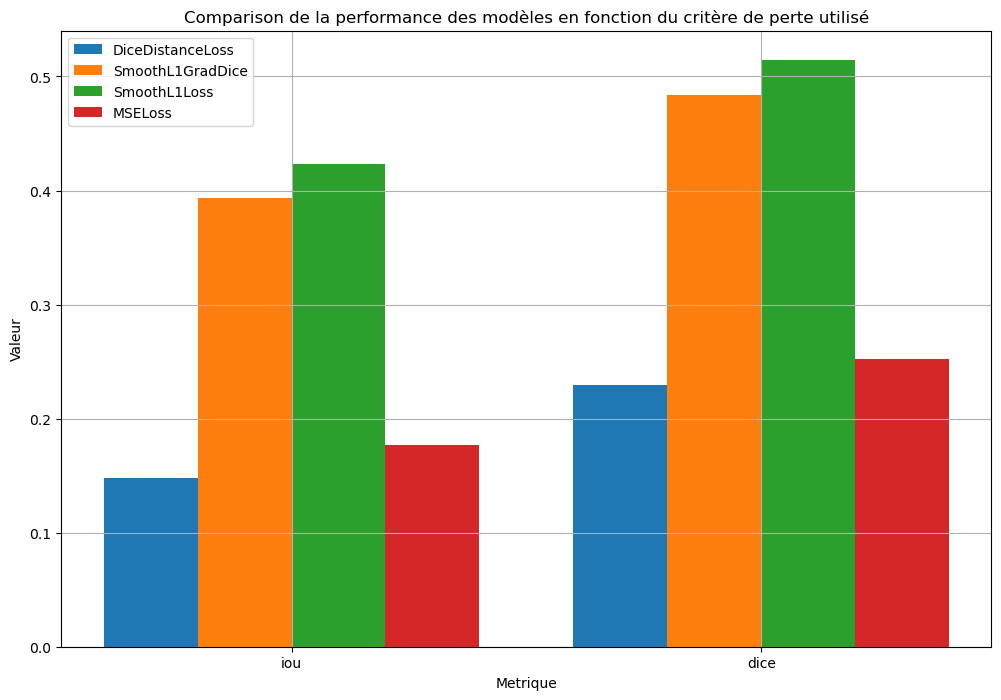

In [186]:
# plotting results

criteria = [c for c in eval_results.keys() if all(m in eval_results[c] for m in ["iou", "dice"])]
metrics = ["iou", "dice"]

if not criteria:
    print("No criteria with required metrics found.")
else:
    x = np.arange(len(metrics))
    width = 0.8 / len(criteria)

    fig, ax = plt.subplots(figsize=(12,8))

    for i, criterion in enumerate(criteria):
        values = [eval_results[criterion][metric] for metric in metrics]
        ax.bar(x + i*width, values, width, label=criterion)

    ax.set_xlabel('Metrique')
    ax.set_ylabel('Valeur')
    ax.set_title('Comparison de la performance des modèles en fonction du critère de perte utilisé')
    ax.set_xticks(x + width*(len(criteria)-1)/2)
    ax.set_xticklabels(metrics)
    ax.legend()
    plt.grid()
    plt.show()

In [496]:
print(eval_results)

{'mse': {'iou_score': 0.35970848443804776, 'dice_coeff': 0.4550672455468388, 'hausdorff_distance': 284.06926570166394}, 'SmoothL1Loss': {'iou_score': 0.44269569225737393, 'dice_coeff': 0.5324788089064312, 'hausdorff_distance': 260.6866204918221}, 'RootDistanceSmoothLoss': {'iou_score': 0.4351903576907442, 'dice_coeff': 0.5248755201849041, 'hausdorff_distance': 267.5562528374771}, 'SmoothL1GradLoss': {'iou_score': 0.39313677281437326, 'dice_coeff': 0.4918571582233219, 'hausdorff_distance': 265.3351712538655}, 'SmoothL1GradDice': {'iou_score': 0.4107551004548706, 'dice_coeff': 0.5046564642491416, 'hausdorff_distance': 266.4312492587517}, 'DiceLoss': {'iou_score': 0.13003473684551986, 'dice_coeff': 0.21930764398250918, 'hausdorff_distance': 269.4245803590698}}
